# Project links

**Github repository**
https://github.com/phkhle/IND320

**Streamlitt app**
https://ind320-h2026.streamlit.app/



# Use of AI

I use AI to help with the plotting part, and for inspiration of how one can plot all features within one plot.

# Resevoir dataset

## Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


## Read in file

In [93]:
df = pd.read_csv('reservoirs.csv')
df

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


## Data analysis

Rename headers to English and understandable.


In [94]:
df = df.rename(columns={
    "dato_Id": "date_Id",
    "omrType": "areaType",
    "omrnr" : "areaNr",	
    "iso_aar": "year",	
    "iso_uke": "week",	
    "fyllingsgrad": "filling_level",	
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filling_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_level_last_week",
    "endring_fyllingsgrad": "change_filling_level"
})

In [95]:
df

,date_Id,areaType,areaNr,year,week,filling_level,capacity_TWh,filling_TWh,next_publication_date,filling_level_last_week,change_filling_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


In [96]:
# Show all columns and their data types
print(df.dtypes)
# Change "date_Id" and "next_publication_date" to datetime format
df['date_Id'] = pd.to_datetime(df['date_Id'])
df['next_publication_date'] = pd.to_datetime(df['next_publication_date'], errors='coerce')

date_Id                     object
areaType                    object
areaNr                       int64
year                         int64
week                         int64
filling_level              float64
capacity_TWh               float64
filling_TWh                float64
next_publication_date       object
filling_level_last_week    float64
change_filling_level       float64
dtype: object


C:\Users\khanh\AppData\Local\Temp\ipykernel_12068\2747876171.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['next_publication_date'] = pd.to_datetime(df['next_publication_date'], errors='coerce')


### Plot each column separately


This code below was inspired by the assignments from DAT200

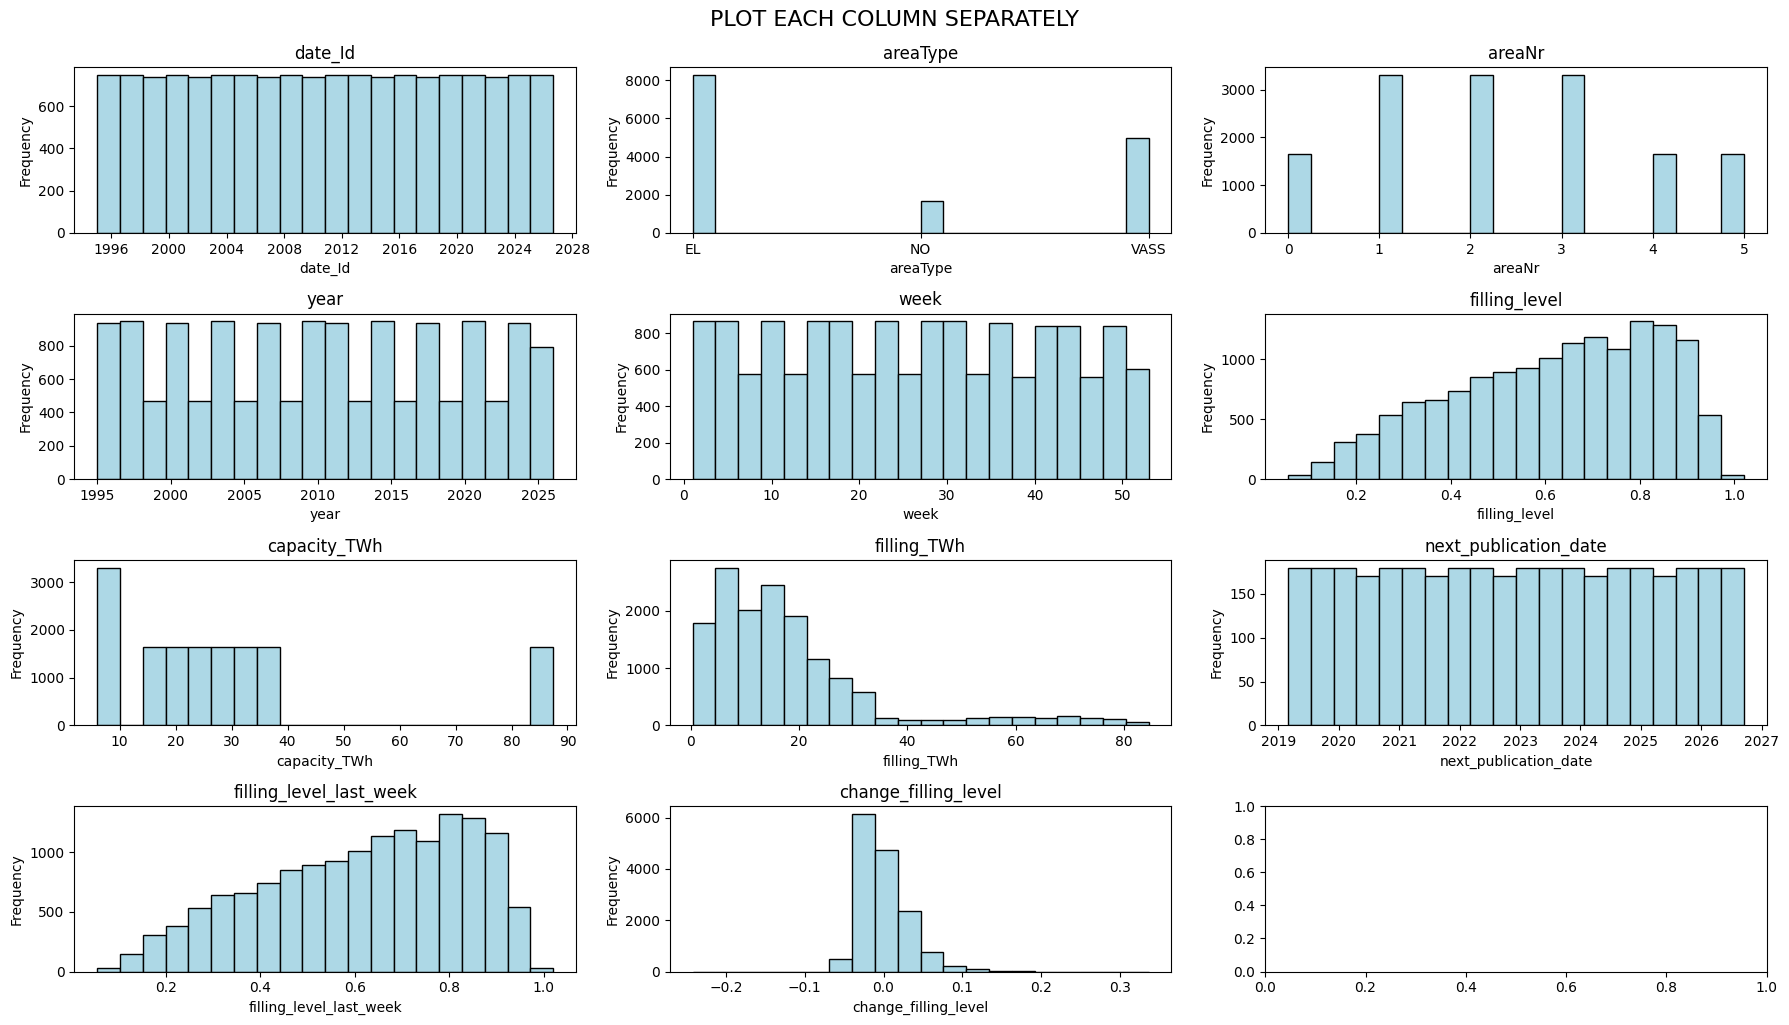

In [97]:
# create a figure and axes using subplots
fig, axes = plt.subplots(nrows = 4, ncols = 3, figsize = (18, 10))
# since ax is an array, we flatten it to plot the histogram
axes = axes.flatten()
for i, fea in enumerate(df.columns):
    ax = axes[i] # Select current axis
    ax.hist(df[fea], bins = 20, color = 'lightblue', edgecolor = 'black')
    ax.set_xlabel(fea)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{fea}')
# adjust layout to prevent overlap of subplots
plt.tight_layout()
# Add a main title to the figure
plt.suptitle('PLOT EACH COLUMN SEPARATELY', fontsize = 16, y = 1.02)
plt.show()

We see that among 11 columns/features, there are:
- 6 categorical features, among that ``week`` and ``year`` are information taken from ``date_Id``
- 5 numerical features

In [104]:
# Summarize statistics of the dataset
df.describe()

,date_Id,areaNr,year,week,filling_level,capacity_TWh,filling_TWh,next_publication_date,filling_level_last_week,change_filling_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,3555,14877.000000,14877.000000
mean,2010-11-07 00:00:00.000000256,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,2022-12-07 13:21:52.405063168,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,2019-02-27 13:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,2021-01-13 13:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,2022-12-07 13:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,2024-10-30 13:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


The statistical summary is more meaningful with numercial features

### Plot all columns together

It was tricky to combine all columns together in one plot and still make it meaningful analysis, given that there are both categorical and numerical features and are in different scale. 

Therefore I tried to divide the plots according to 3 ``areaType`` (EL, NO, VASS), then ignore the ``year`` and ``week`` features since it can be implied from the ``date_Id``. ``next_publication_date`` is taken away since it is in the datetime format and very difficult to include in the plot. 

Regarding ``areaNr`` we have 5 values (0, 1, 2, 3, 4, 5), comparing to 3 values in ``areaType``. I therefore want to check if for every ``areaType`` there are 5 values in ``areaNr``

In [111]:
# Show unique combinations of areaType and areaNr
df[["areaType", "areaNr"]].drop_duplicates().sort_values(["areaType", "areaNr"])

,areaType,areaNr
1,EL,1
131,EL,2
3,EL,3
0,EL,4
9,EL,5
8265,NO,0
9924,VASS,1
9918,VASS,2
9919,VASS,3


Then we see that there are 5 ``areaNr`` for area EL; but only 1 for NO and 3 for VASS. Hence, I want to plot each ``areaType`` and ``areaNr`` combination separately

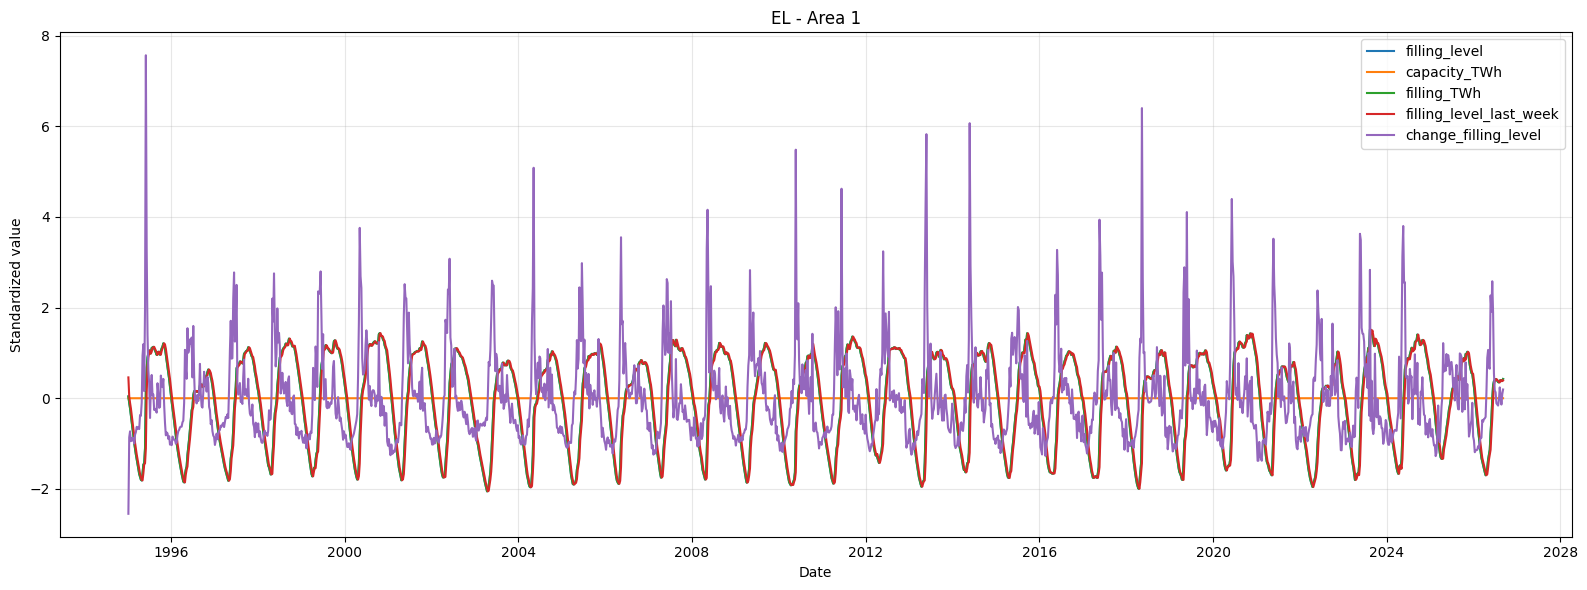

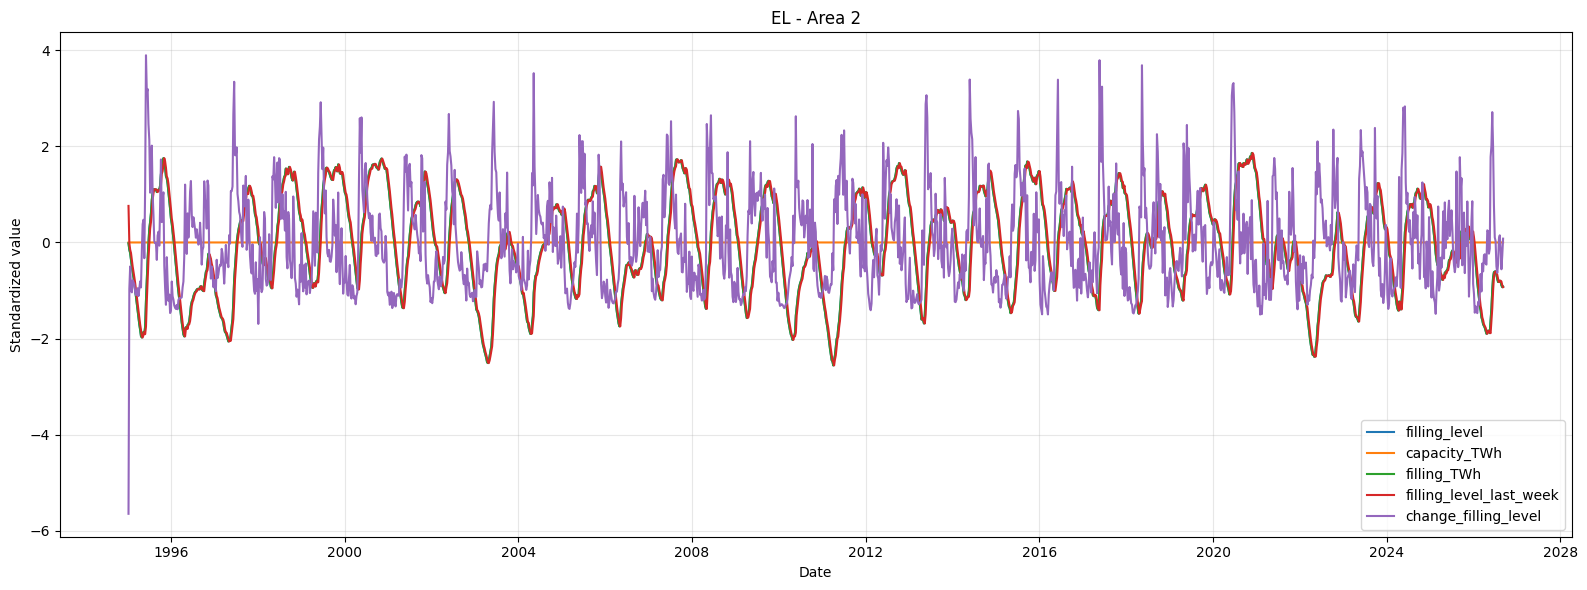

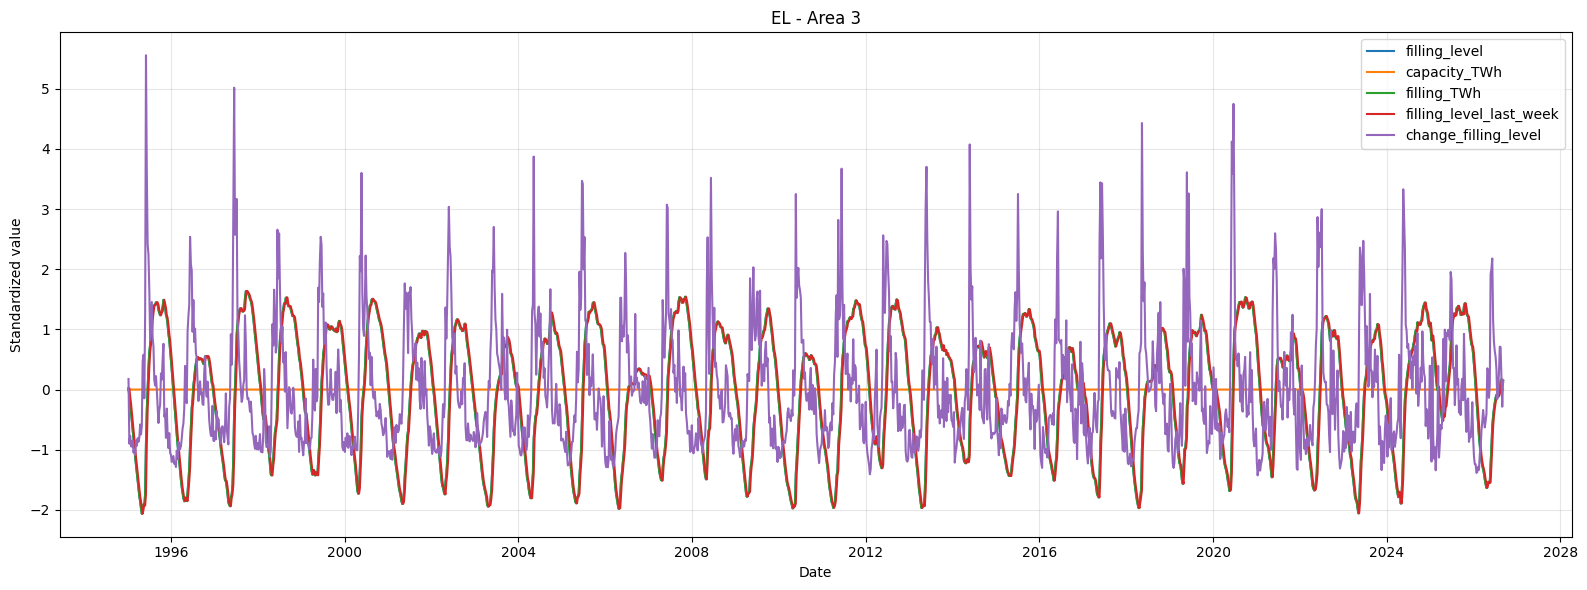

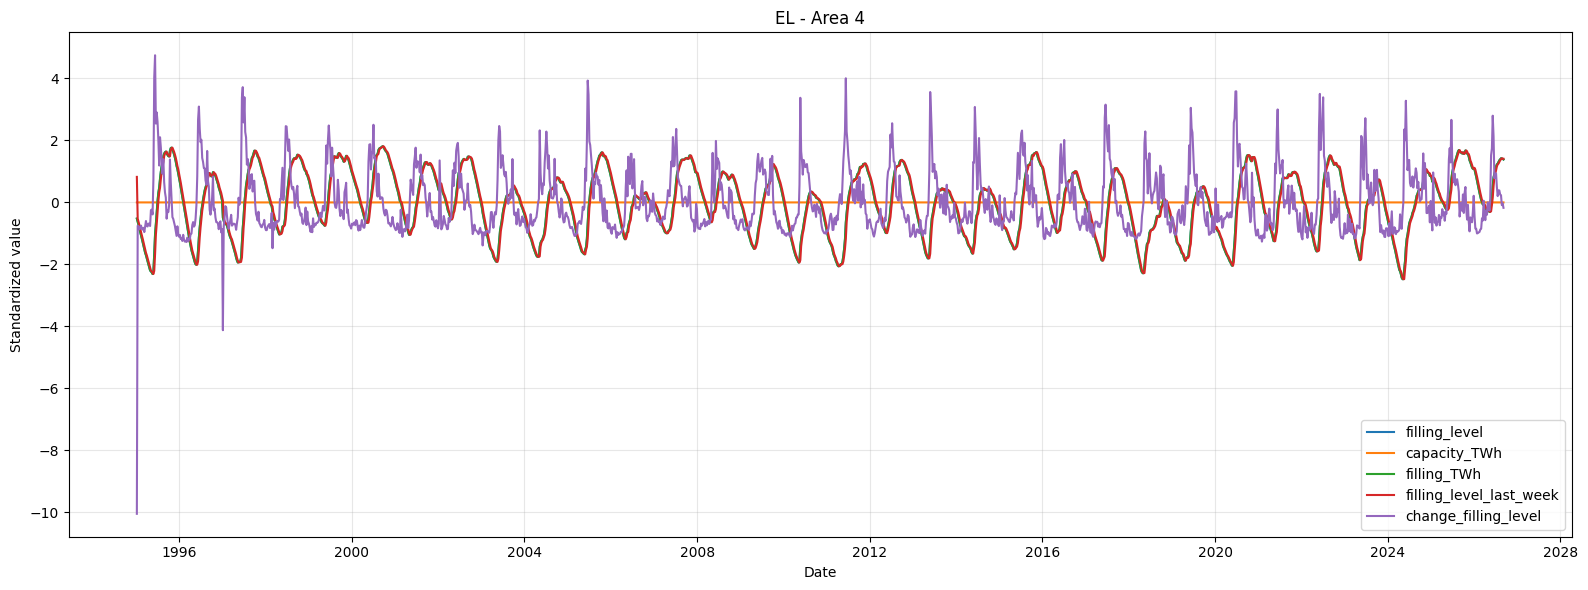

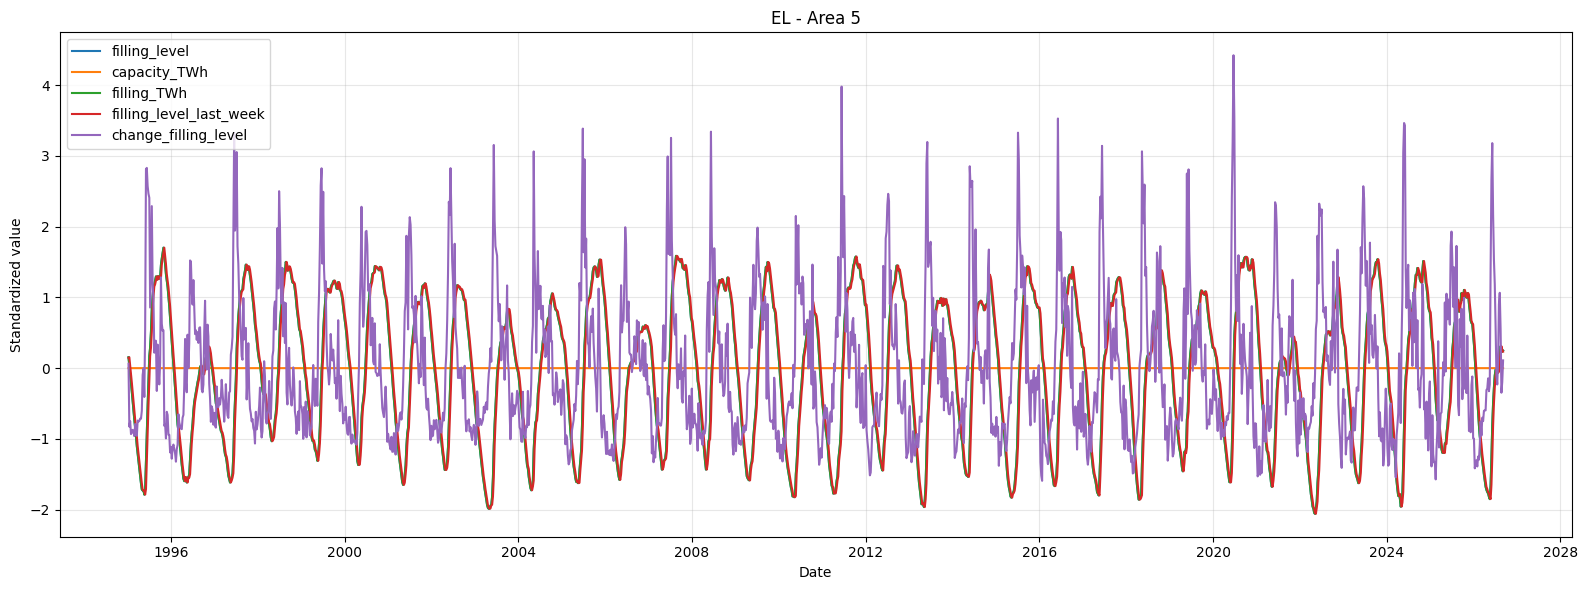

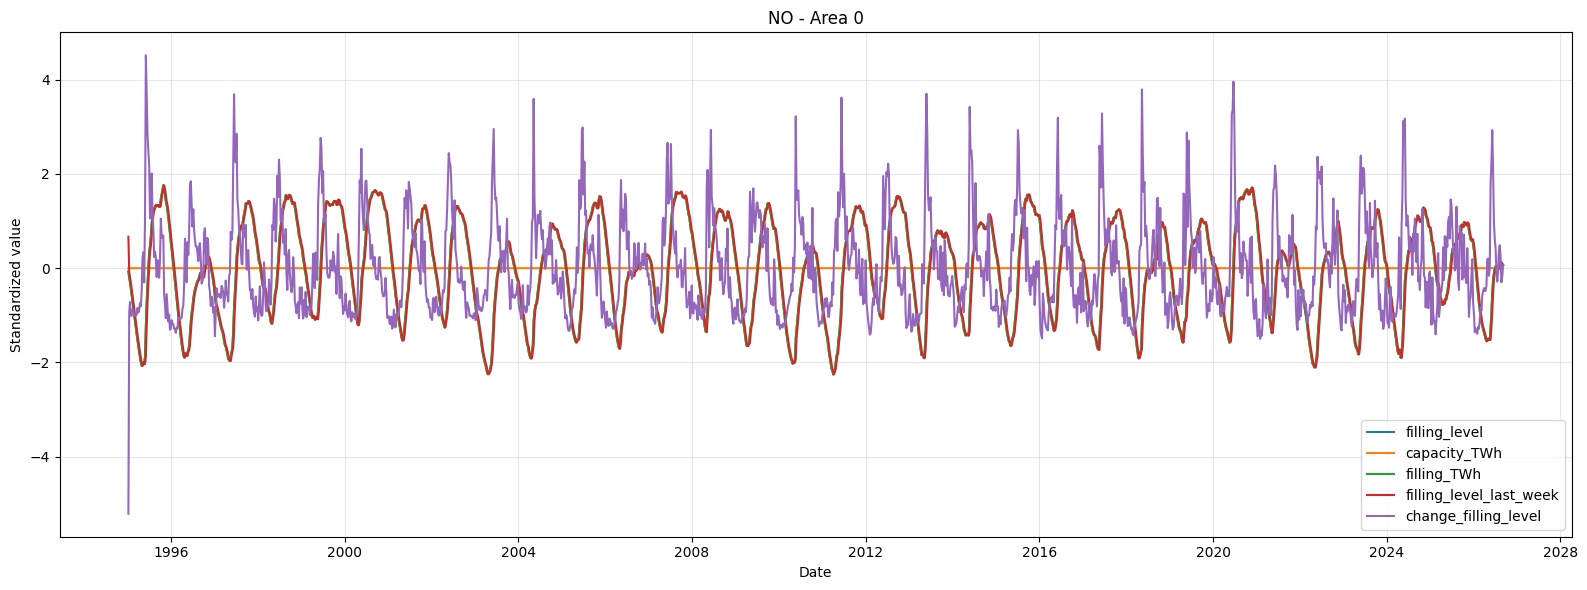

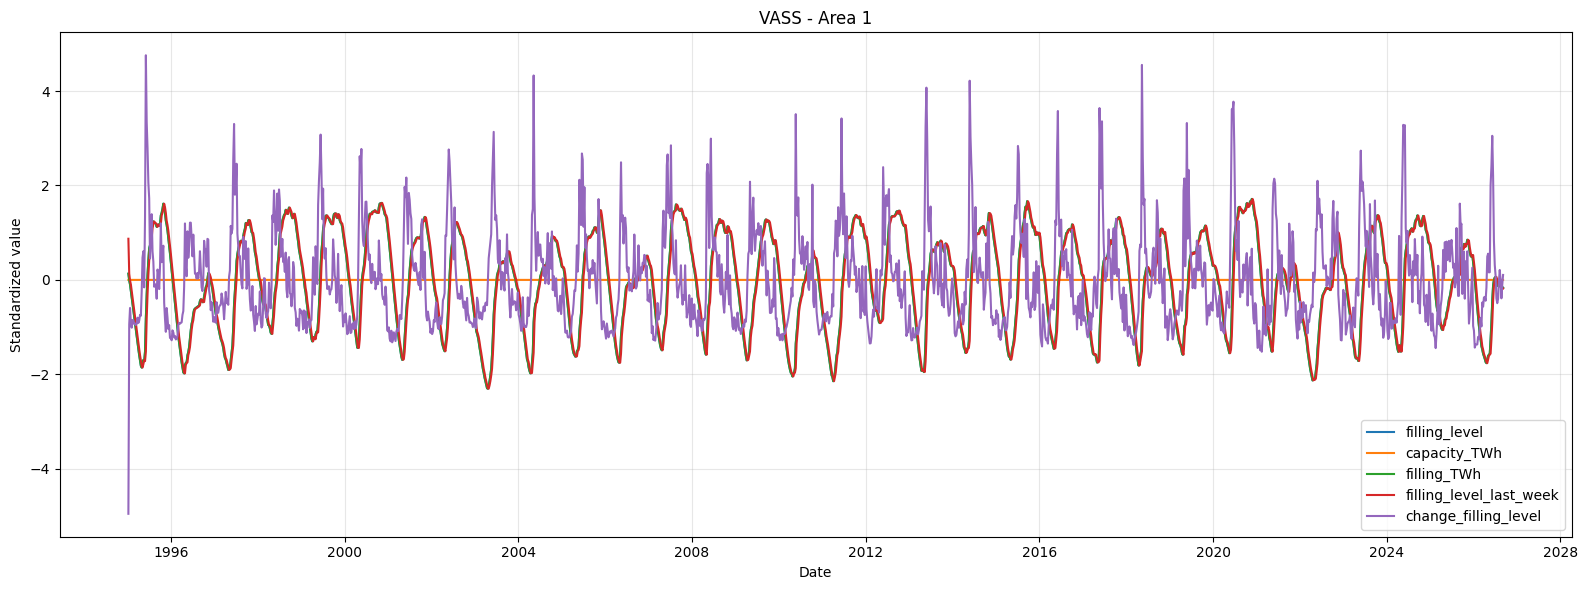

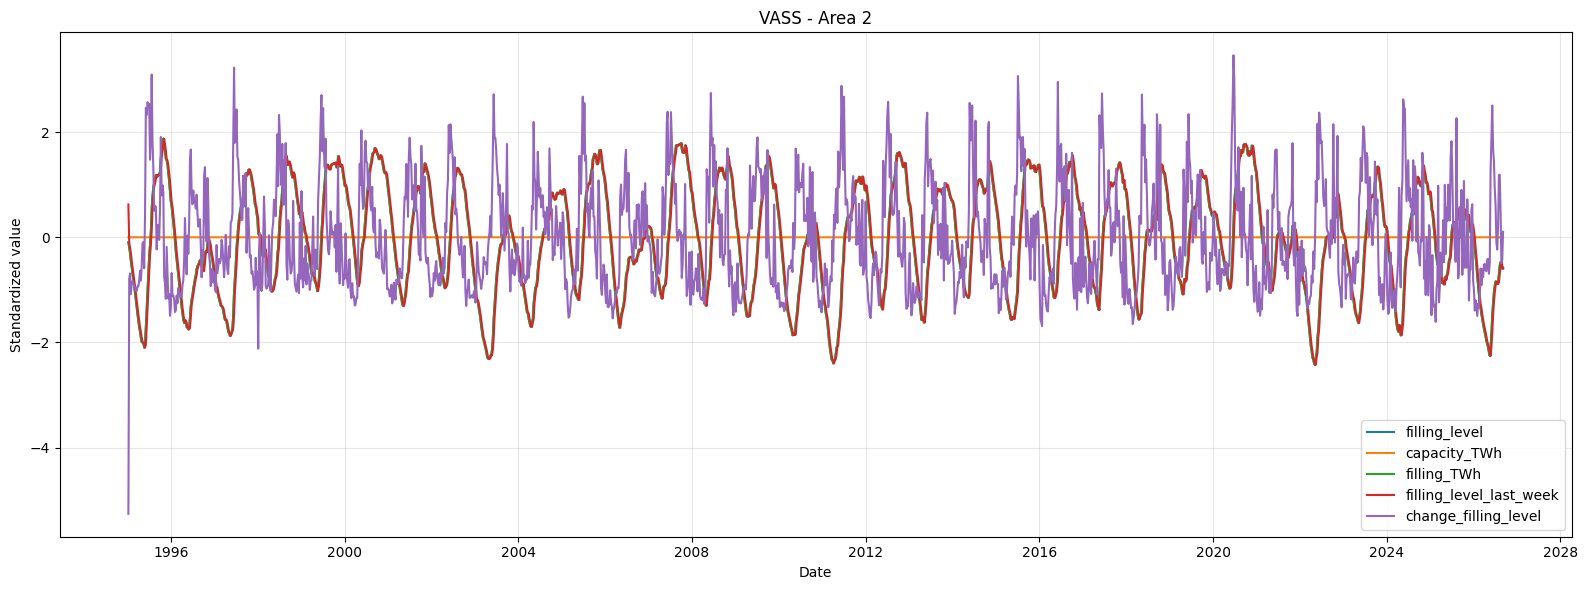

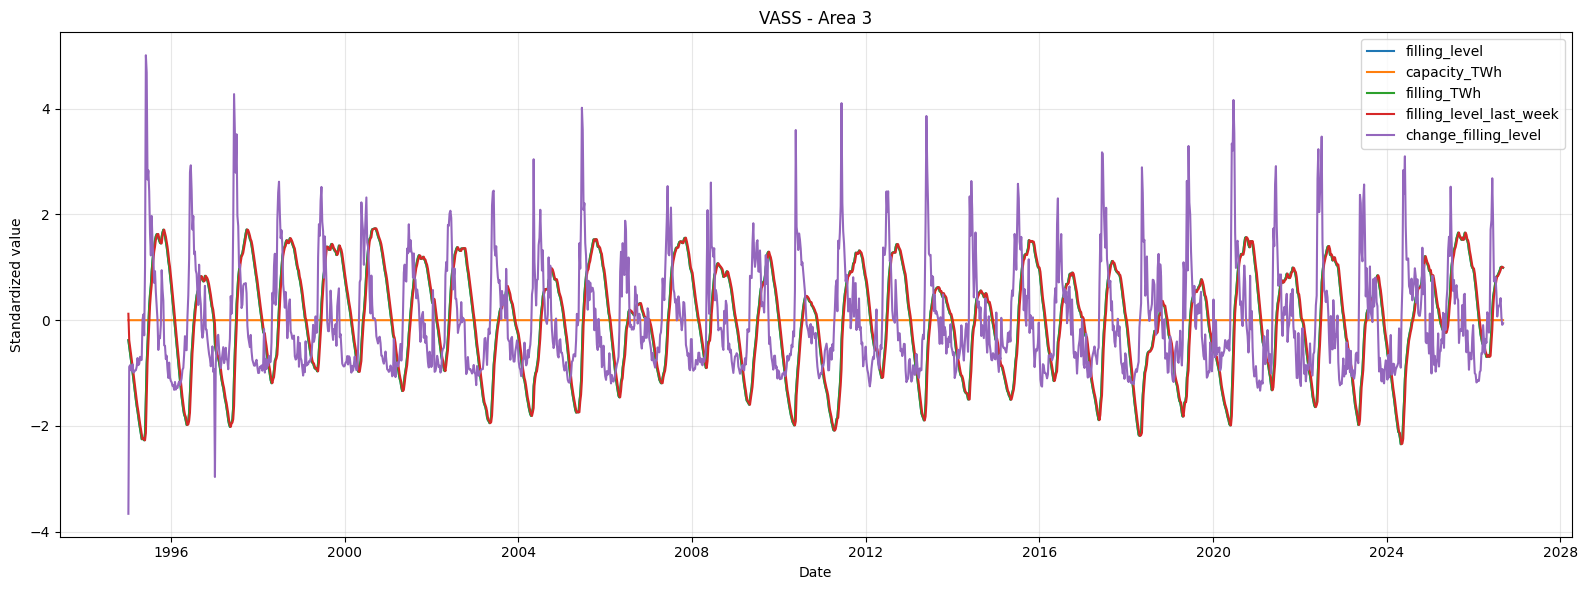

In [117]:
numerical_plot_cols = [
    "filling_level",
    "capacity_TWh",
    "filling_TWh",
    "filling_level_last_week",
    "change_filling_level"
]

# Plot each areaType and areaNr combination separately
# Filter the temporary DataFrame ``temp`` for the specified areaType and areaNr
for (area_type, area_nr), temp in df.groupby(["areaType", "areaNr"]):

    # Sort the temporary DataFrame by date_Id
    temp = temp.sort_values("date_Id").copy()

    # Standardize the numerical columns using StandardScaler
    scaler = StandardScaler()
    # Fit the scaler to the numerical columns and transform them
    temp[numerical_plot_cols] = scaler.fit_transform(temp[numerical_plot_cols])

    plt.figure(figsize=(16, 6))

    for col in numerical_plot_cols:
        plt.plot(
            temp["date_Id"],
            temp[col],
            label=col
        )

    plt.title(f"{area_type} - Area {area_nr}")
    plt.xlabel("Date")
    plt.ylabel("Standardized value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()